EDA + Preprocessing

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
# 2. Load Dataset
data_path = '../dataset/data_for_preprocessing.csv' 
df = pd.read_csv(data_path)

# Quick look at data
print("First 5 rows:\n", df.head())
print("\nDataset info:\n", df.info())
print("\nSummary statistics:\n", df.describe())

First 5 rows:
    Unnamed: 0                                               Text Author
0           0  This study investigates the chemical compositi...     AI
1           1  This study explores the cultural history of oi...     AI
2           2   Isolation of human peripheral blood mononucle...  Human
3           3   Dynamic Bayesian Networks (DBNs) are probabil...  Human
4           4   Within volleyball, performance analysis is em...  Human
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6069 entries, 0 to 6068
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6069 non-null   int64 
 1   Text        6069 non-null   object
 2   Author      6069 non-null   object
dtypes: int64(1), object(2)
memory usage: 142.4+ KB

Dataset info:
 None

Summary statistics:
         Unnamed: 0
count  6069.000000
mean   3034.000000
std    1752.113723
min       0.000000
25%    1517.000000
50%    3034.000000
75%    4551.000000


In [9]:
# 3. Check duplicates / missing values
print("\nNumber of missing values:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of missing values:
 Unnamed: 0    0
Text          0
Author        0
dtype: int64

Number of duplicate rows: 0


In [10]:
print(df.columns)

Index(['Unnamed: 0', 'Text', 'Author'], dtype='object')


In [11]:
# Drop missing or duplicate rows if any
df.dropna(subset=['Text'], inplace=True)
df.drop_duplicates(inplace=True)

In [12]:
# 4. Text Cleaning Function
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace
    return text

In [13]:
# Apply cleaning
df['cleaned_text'] = df['Text'].apply(clean_text)

In [14]:
# 5. Basic Text Stats
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

In [15]:
# Average text length per class
avg_len = df.groupby('Author')['text_length'].mean()
print("\nAverage text length per class:\n", avg_len)


Average text length per class:
 Author
AI        43.456500
Human    260.794667
Name: text_length, dtype: float64


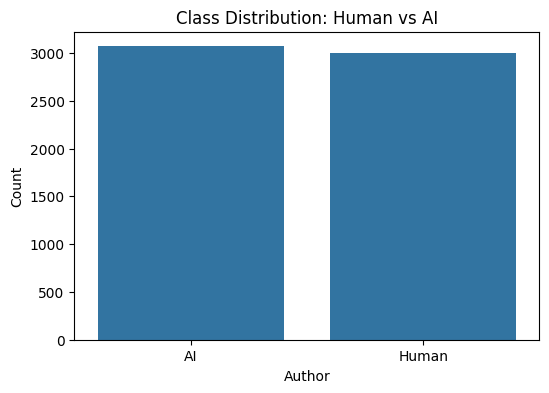

In [16]:
# 6. Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Author', data=df)
plt.title('Class Distribution: Human vs AI')
plt.xlabel('Author')
plt.ylabel('Count')
plt.show()

In [17]:
# 7. Optional: Word Clouds

# Separate human and AI texts
human_text = " ".join(df[df['Author']=='Human']['cleaned_text'])
ai_text = " ".join(df[df['Author']=='AI']['cleaned_text'])

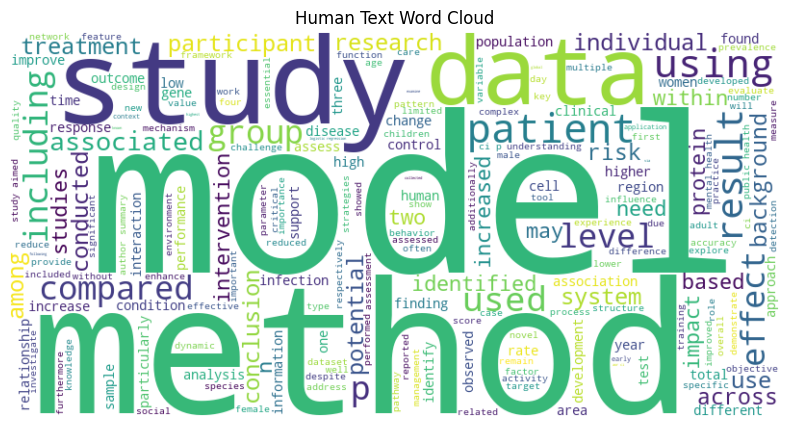

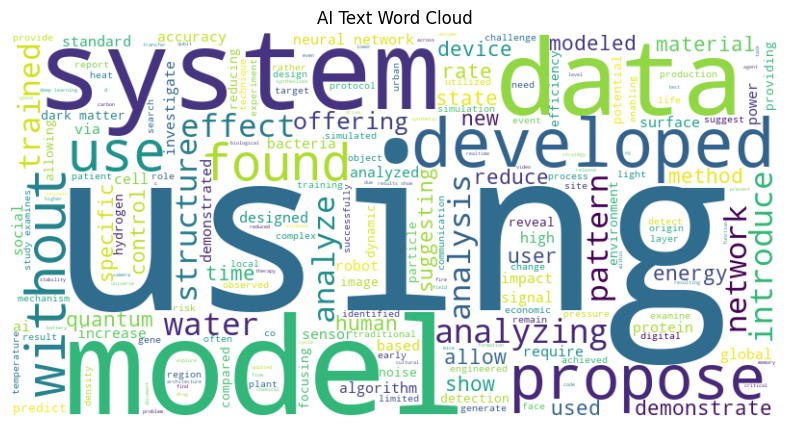

In [18]:
# Word cloud for Human
if human_text.strip():
    wordcloud_human = WordCloud(width=800, height=400, background_color='white').generate(human_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud_human, interpolation='bilinear')
    plt.axis('off')
    plt.title("Human Text Word Cloud")
    plt.show()
else:
    print("No Human text found for word cloud.")

# Word cloud for AI
if ai_text.strip():
    wordcloud_ai = WordCloud(width=800, height=400, background_color='white').generate(ai_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud_ai, interpolation='bilinear')
    plt.axis('off')
    plt.title("AI Text Word Cloud")
    plt.show()
else:
    print("No AI text found for word cloud.")


Feature Extraction

In [20]:
# Features (X) and Labels (y)
X_text = df['cleaned_text']
y = df['Author']

print("Sample text:\n", X_text.iloc[0])
print("\nSample label:", y.iloc[0])

Sample text:
 this study investigates the chemical composition of thermal springs in afyonkarahisar assessing their potential for health tourism

Sample label: AI


In [21]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,   # limit features (important for performance)
    ngram_range=(1,2)     # unigrams + bigrams
)

# Fit and transform text data
X = tfidf.fit_transform(X_text)

print("TF-IDF shape:", X.shape)

TF-IDF shape: (6069, 10000)


In [22]:
import os
import joblib

# Ensure the models directory exists
os.makedirs("models", exist_ok=True)

# Save the vectorizer
joblib.dump(tfidf, '../models/vectorizer.pkl')
print("Vectorizer saved!")

Vectorizer saved!


In [23]:
# Convert one sample to vector
sample_vector = tfidf.transform([X_text.iloc[0]])

print("Sample vector shape:", sample_vector.shape)

Sample vector shape: (1, 10000)


Train and Evaluate Models

In [24]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 4855
Test samples: 1214


In [25]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Linear SVM": LinearSVC(max_iter=500),
    "Multinomial NB": MultinomialNB()
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Linear SVM trained successfully!
Multinomial NB trained successfully!



--- Logistic Regression ---
Accuracy: 0.9901
Classification Report:
               precision    recall  f1-score   support

          AI       0.98      1.00      0.99       614
       Human       1.00      0.98      0.99       600

    accuracy                           0.99      1214
   macro avg       0.99      0.99      0.99      1214
weighted avg       0.99      0.99      0.99      1214



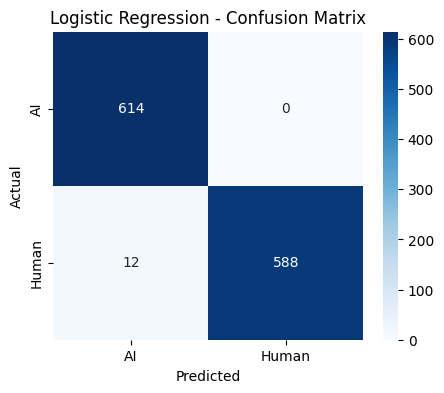


--- Linear SVM ---
Accuracy: 0.9942
Classification Report:
               precision    recall  f1-score   support

          AI       0.99      1.00      0.99       614
       Human       1.00      0.99      0.99       600

    accuracy                           0.99      1214
   macro avg       0.99      0.99      0.99      1214
weighted avg       0.99      0.99      0.99      1214



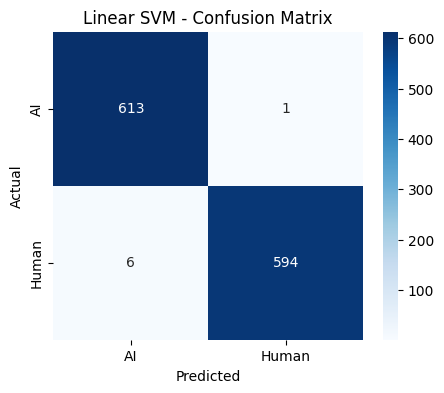


--- Multinomial NB ---
Accuracy: 0.9679
Classification Report:
               precision    recall  f1-score   support

          AI       0.97      0.97      0.97       614
       Human       0.97      0.97      0.97       600

    accuracy                           0.97      1214
   macro avg       0.97      0.97      0.97      1214
weighted avg       0.97      0.97      0.97      1214



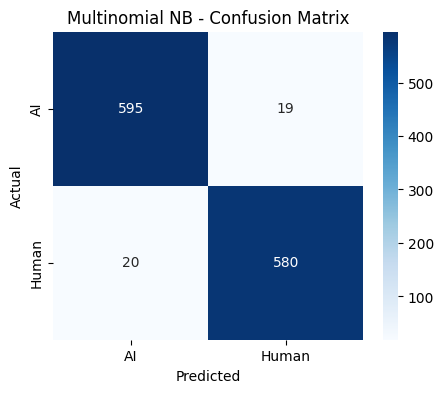

In [26]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n--- {name} ---")
    print("Accuracy:", round(acc, 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['AI','Human'], yticklabels=['AI','Human'])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

Hyperparameter Tuning

In [27]:
# Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=500),
    {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']},
    cv=5,
    scoring='accuracy'
)
lr_grid.fit(X_train, y_train)

print("LR Best:", lr_grid.best_params_, lr_grid.best_score_)

# Linear SVC
svc_grid = GridSearchCV(
    LinearSVC(),
    {'C': [0.01, 0.1, 1, 10], 'max_iter': [500, 1000]},
    cv=5,
    scoring='accuracy'
)
svc_grid.fit(X_train, y_train)

print("SVM Best:", svc_grid.best_params_, svc_grid.best_score_)

LR Best: {'C': 10, 'solver': 'liblinear'} 0.9948506694129764
SVM Best: {'C': 10, 'max_iter': 500} 0.9964984552008239


In [28]:
# Example pipeline with scaling
pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # with_mean=False for sparse matrices
    ('svc', LinearSVC(dual=False))
])

param_grid = {
    'svc__C': [0.01, 0.1, 1, 10],
    'svc__max_iter': [5000, 10000]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Params: {'svc__C': 0.01, 'svc__max_iter': 5000}
Best CV Accuracy: 0.9946446961894952


In [29]:
# Choose best model + apply calibration if needed

if svc_grid.best_score_ >= lr_grid.best_score_:
    print("Using LinearSVC with calibration")

    best_svm = svc_grid.best_estimator_
    best_model = CalibratedClassifierCV(best_svm, method='sigmoid', cv=5)
    best_model.fit(X_train, y_train)

else:
    print("Using Logistic Regression")

    best_model = lr_grid.best_estimator_
    best_model.fit(X_train, y_train)

# Save final model
joblib.dump(best_model, '../models/classifier.pkl')
print("Final model saved!")

Using LinearSVC with calibration
Final model saved!



Final Model Performance:
Accuracy: 0.9958813838550247
              precision    recall  f1-score   support

          AI       0.99      1.00      1.00       614
       Human       1.00      0.99      1.00       600

    accuracy                           1.00      1214
   macro avg       1.00      1.00      1.00      1214
weighted avg       1.00      1.00      1.00      1214



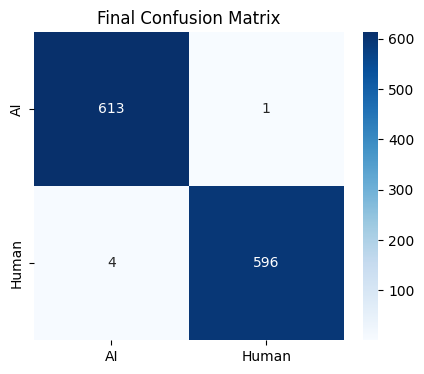

In [30]:
y_pred = best_model.predict(X_test)

print("\nFinal Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
labels = list(best_model.classes_)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.title("Final Confusion Matrix")
plt.show()

Visualization

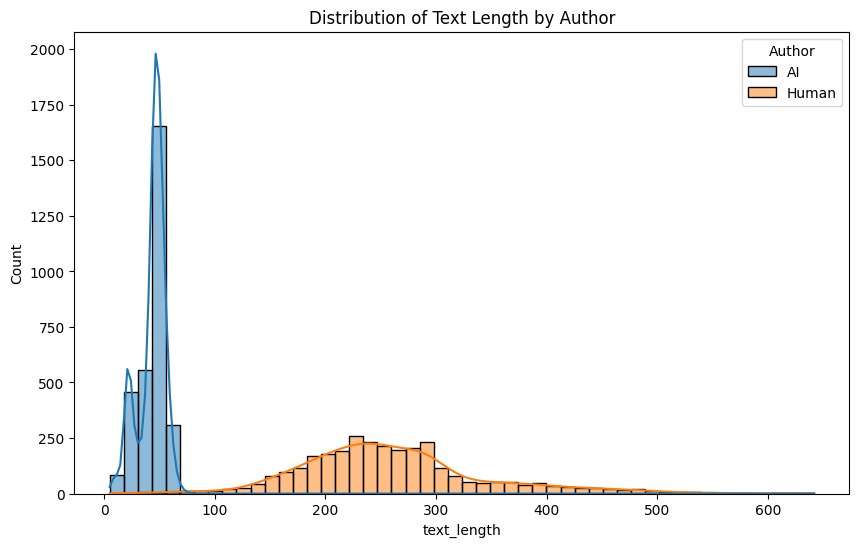

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='Author', kde=True, bins=50)
plt.title("Distribution of Text Length by Author")
plt.show()